In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = sns.load_dataset('titanic')

In [13]:
print( df.head())


   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [14]:
print( df.dtypes)

survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object


In [15]:
print( df.shape)

(891, 15)


In [23]:
df = df.dropna(subset=["pclass", "embarked", "age", "fare", "survived", "sex"])

embarked_pos = {"S": 1, "C": 2, "Q": 3}
df["x"] = df["embarked"].map(embarked_pos)



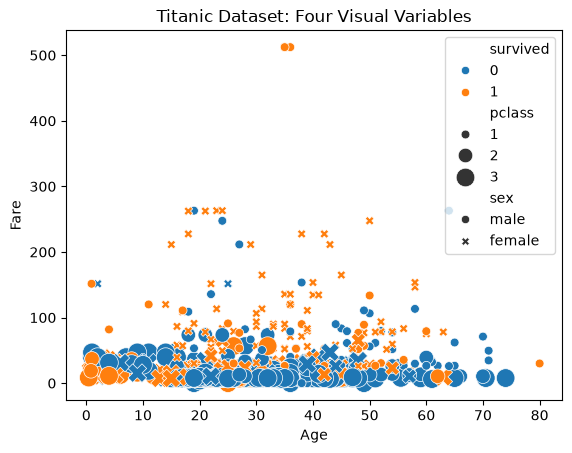

In [24]:
sns.scatterplot(
    data=df,
    x="age",
    y="fare",
    hue="survived",
    style="sex",
    size="pclass",
    sizes=(40, 180)
)

plt.title("Titanic Dataset: Four Visual Variables")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

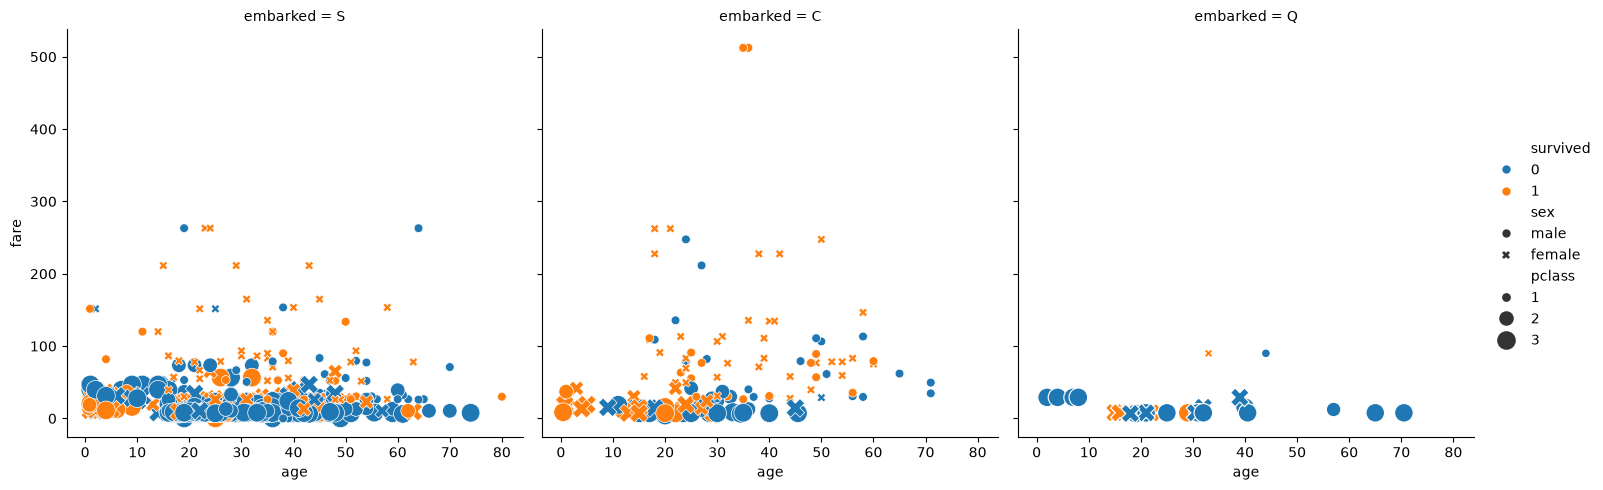

In [25]:
sns.relplot(
    data=df,
    x="age",
    y="fare",
    hue="survived",
    style="sex",
    size="pclass",
    col="embarked",
    sizes=(40, 180)
)

plt.show()

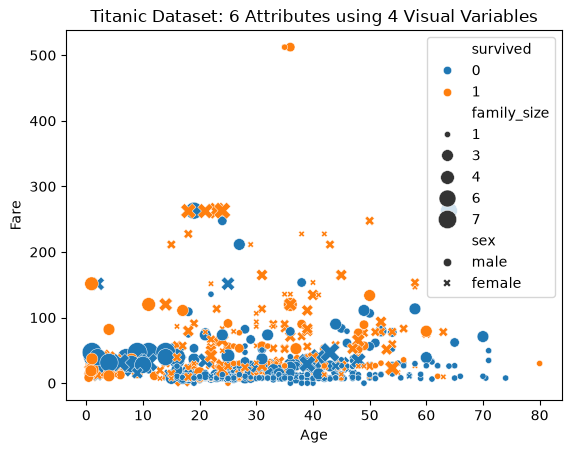

In [26]:
df["family_size"] = df["sibsp"] + df["parch"]   + 1
sns.scatterplot(
    data=df,
    x="age",
    y="fare",
    hue="survived",
    style="sex",
    size="family_size",
    sizes=(20, 200)
)

plt.title("Titanic Dataset: 6 Attributes using 4 Visual Variables")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

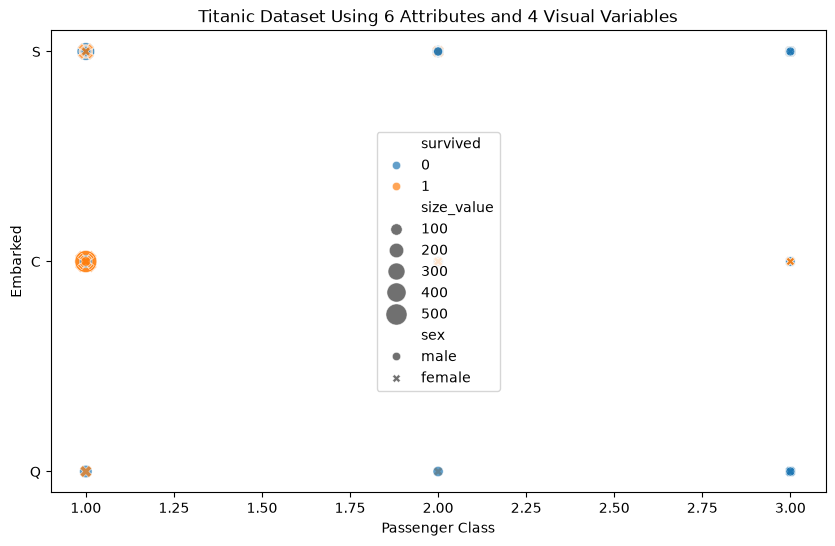

In [36]:
df = df.dropna(subset=["age", "fare", "sex", "survived", "pclass", "sibsp", "parch"])


# Combine fare and age into one size value
df["size_value"] = df["fare"] + df["age"]

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="pclass",
    y="embarked",
    hue="survived",
    style="sex",
    size="size_value",
    sizes=(30, 250),
    alpha=0.7
)

plt.xlabel("Passenger Class")
plt.ylabel("Embarked")
plt.title("Titanic Dataset Using 6 Attributes and 4 Visual Variables")
plt.show()

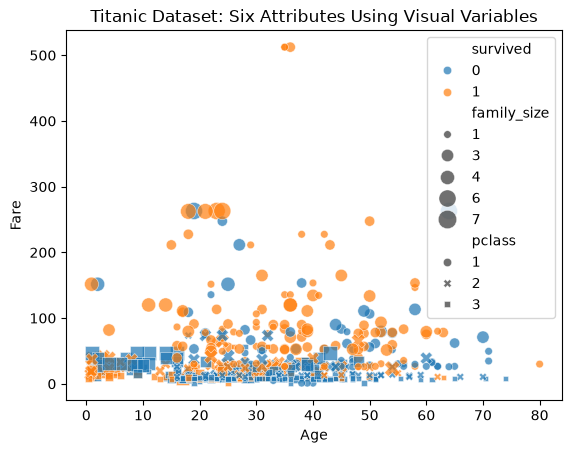

In [39]:
sns.scatterplot(
    data=df,
    x="age",
    y="fare",
    hue="survived",
    style="pclass",
    size="family_size",
    sizes=(30, 200),
    alpha=0.7
)

plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Titanic Dataset: Six Attributes Using Visual Variables")
plt.show()

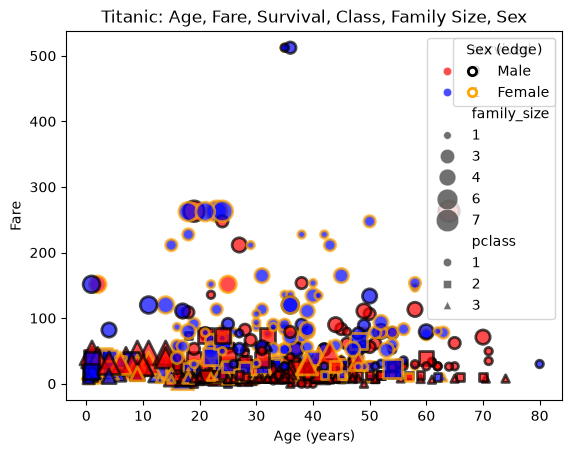

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Load and clean
df = sns.load_dataset("titanic").dropna(subset=["age", "fare", "sex", "survived", "pclass", "sibsp", "parch"])
df["family_size"] = df["sibsp"] + df["parch"] + 1

# Scatter plot: position, color, shape, size
ax = sns.scatterplot(
    data=df, x="age", y="fare",
    hue="survived", palette={0: "red", 1: "blue"},   # color (fill)
    style="pclass", markers={1: "o", 2: "s", 3: "^"}, # shape
    size="family_size", sizes=(30, 300),              # size
    alpha=0.7,
)

# Sixth attribute: edge color = sex
ax.collections[0].set_edgecolor(df["sex"].map({"male": "black", "female": "orange"}))
ax.collections[0].set_linewidth(2)

# Extra legend for sex
seaborn_legend = ax.get_legend()
sex_legend = ax.legend(
    handles=[Line2D([], [], marker="o", ls="", mfc="white", mec=c, mew=2, label=l)
             for l, c in [("Male", "black"), ("Female", "orange")]],
    title="Sex (edge)", loc="upper right",
)
ax.add_artist(seaborn_legend)

ax.set_xlabel("Age (years)")
ax.set_ylabel("Fare")
ax.set_title("Titanic: Age, Fare, Survival, Class, Family Size, Sex")
plt.show()

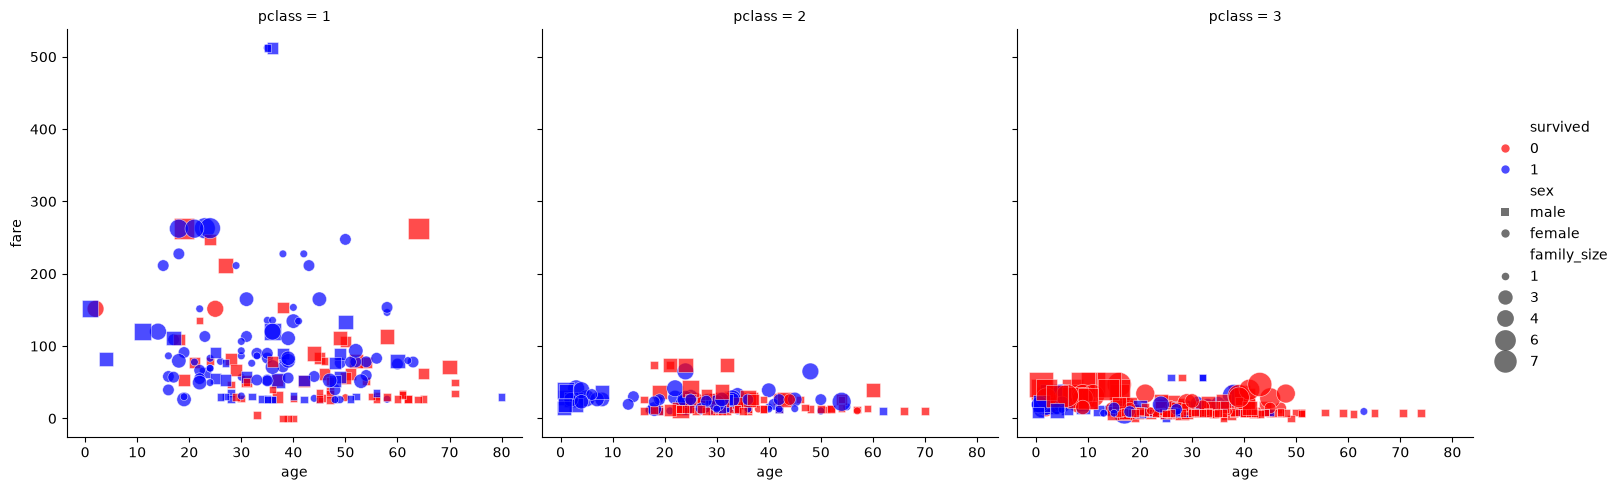

In [43]:
sns.relplot(
    data=df, x="age", y="fare",
    hue="survived", palette={0: "red", 1: "blue"},   # color
    style="sex", markers={"male": "s", "female": "o"}, # shape
    size="family_size", sizes=(30, 300),             # size
    col="pclass",                                    # sixth attribute
    alpha=0.7,
)
plt.show()

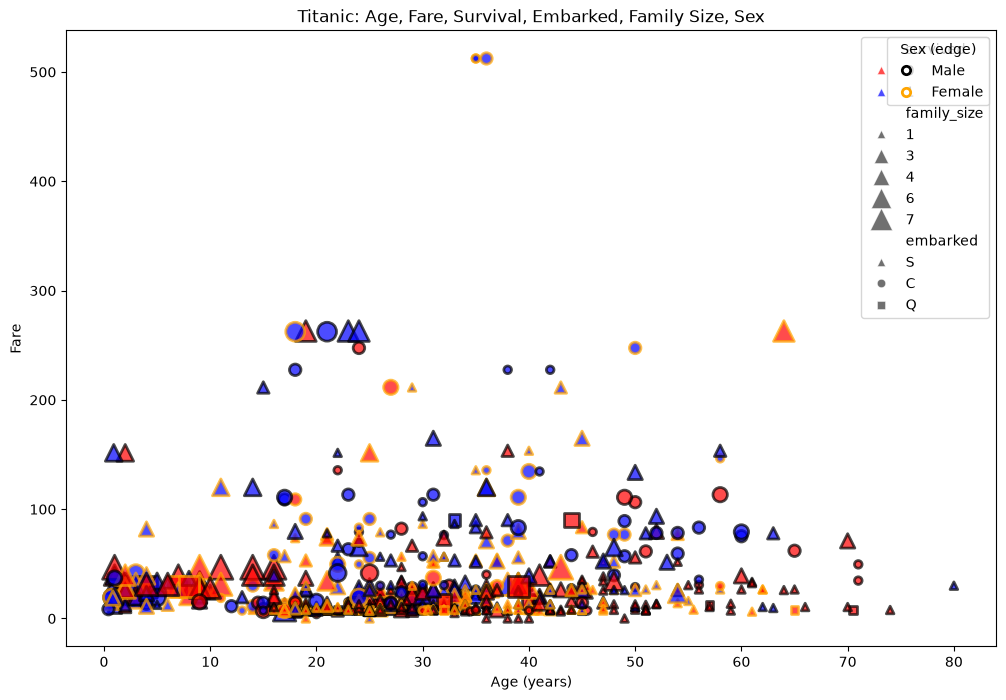

In [46]:
fig, ax = plt.subplots(figsize=(12, 8))   # width, height in inches

sns.scatterplot(
    data=df, x="age", y="fare",
    hue="survived", palette={0: "red", 1: "blue"},
    style="embarked", markers={"C": "o", "Q": "s", "S": "^"},
    size="family_size", sizes=(30, 300),
    alpha=0.7,
    ax=ax,                                
)


# Sixth attribute: edge color = sex
ax.collections[0].set_edgecolor(df["sex"].map({"male": "black", "female": "orange"}))
ax.collections[0].set_linewidth(2)

# Extra legend for sex
seaborn_legend = ax.get_legend()
ax.legend(
    handles=[Line2D([], [], marker="o", ls="", mfc="white", mec=c, mew=2, label=l)
             for l, c in [("Male", "black"), ("Female", "orange")]],
    title="Sex (edge)", loc="upper right",
)
ax.add_artist(seaborn_legend)

ax.set_xlabel("Age (years)")
ax.set_ylabel("Fare")
ax.set_title("Titanic: Age, Fare, Survival, Embarked, Family Size, Sex")
plt.show()
